In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
np.random.seed(42)


# Jupyter visualization settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [2]:
# 导入数据
iris = load_iris()
df = pd.DataFrame({'sepal_length': iris.data[:, 0],
                   'sepal_width': iris.data[:, 1],
                   'species': iris.target})
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal_length,sepal_width,species
0,5.1,3.5,setosa
1,4.9,3.0,setosa
2,4.7,3.2,setosa
3,4.6,3.1,setosa
4,5.0,3.6,setosa


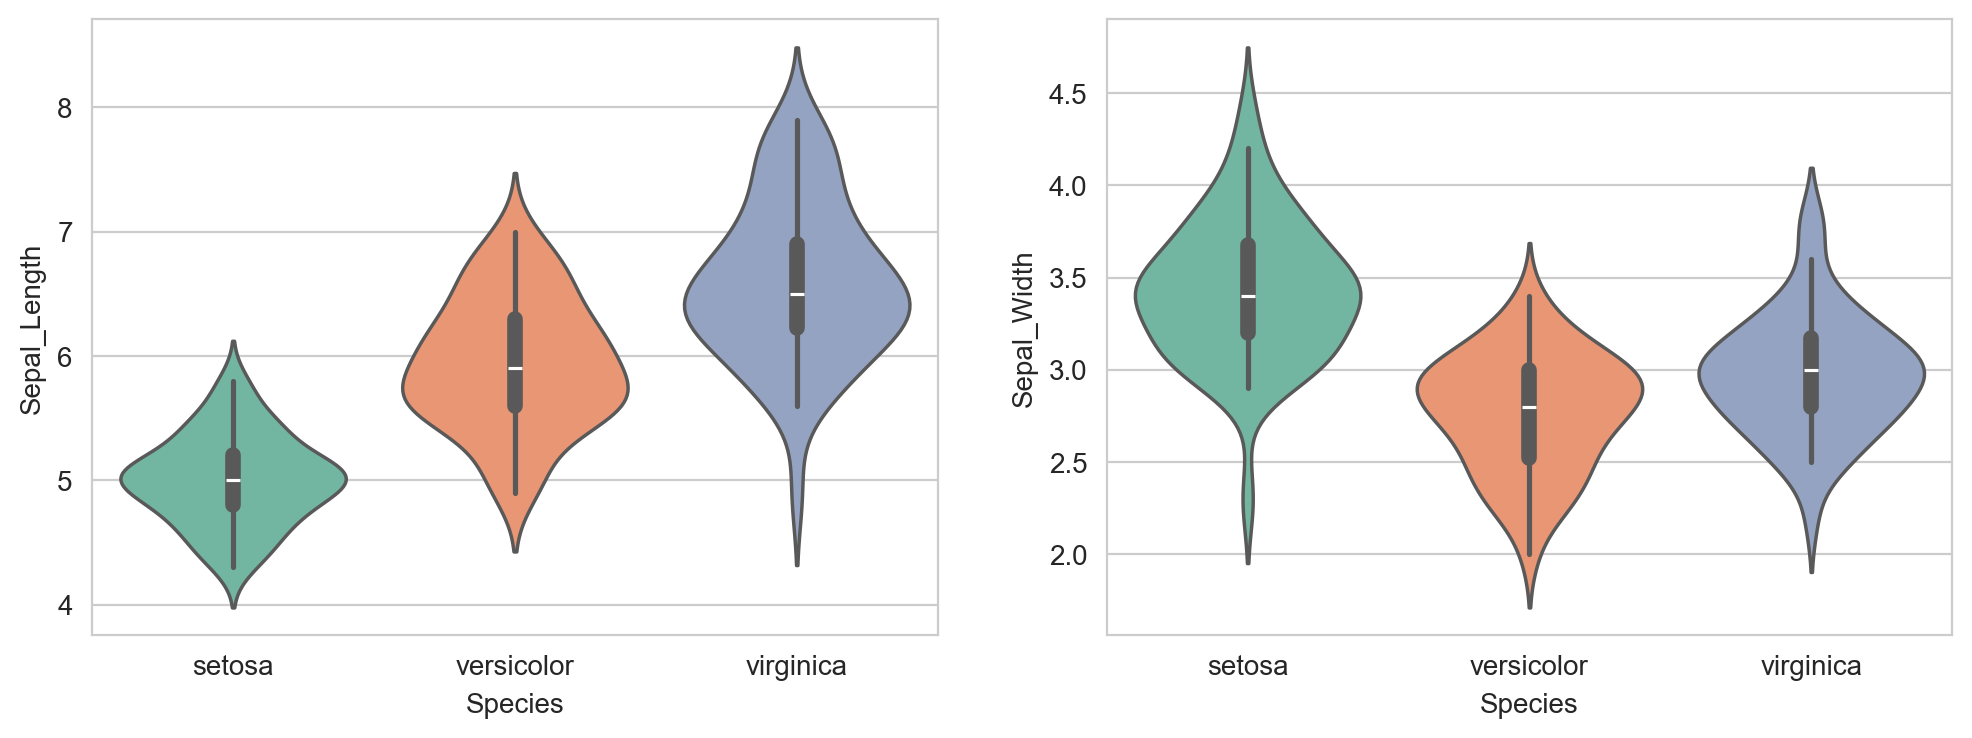

In [3]:
# 小提琴图
plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.violinplot(x='species', y='sepal_length', data=df, hue='species', palette='Set2')
plt.xlabel('Species')
plt.ylabel('Sepal_Length')
plt.subplot(122)
sns.violinplot(x='species', y='sepal_width', data=df, hue='species', palette='Set2')
plt.xlabel('Species')
plt.ylabel('Sepal_Width')
plt.show()

In [4]:
# 单因素方差分析（ANOVA）
# 方式一：使用stats.f_oneway，不能输出方差分析表，但是直观
setosa = df[df['species']=='setosa']['sepal_length'].values
versicolor = df[df['species']=='versicolor']['sepal_length'].values
virginica = df[df['species']=='virginica']['sepal_length'].values

f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
print("ANOVA结果:")
print(f"F统计量: {f_stat:.4f}")
print(f"P值: {p_value:.4f}")
if p_value < 0.05:
    print("拒绝原假设：不同物种的花萼长度均值存在显著差异。")
else:
    print("不拒绝原假设：不同物种的花萼长度均值不存在显著差异。")

ANOVA结果:
F统计量: 119.2645
P值: 0.0000
拒绝原假设：不同物种的花萼长度均值存在显著差异。


In [5]:
# 单因素方差分析（ANOVA）
# 方式二：转换为线性回归模型，得到等价的F检验结果，并输出方差分析表
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('sepal_width ~ C(species)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA结果:")
print(anova_table)
if anova_table.iloc[0, -1] < 0.05:
    print("拒绝原假设：不同物种的花萼宽度均值存在显著差异。")
else:
    print("不拒绝原假设：不同物种的花萼宽度均值不存在显著差异。")

ANOVA结果:
               sum_sq     df         F        PR(>F)
C(species)  11.344933    2.0  49.16004  4.492017e-17
Residual    16.962000  147.0       NaN           NaN
拒绝原假设：不同物种的花萼宽度均值存在显著差异。
